<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Locked_Running_Response_Test_V31_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V31 — Locked Non-Doorway Running-Response Observable Test

**Title:** A First Locked Non-Doorway Running-Response Test of an Electron-Like Packet in the ECSM Framework

This notebook freezes the inherited ECSM electron-like packet stack through V30 and compares the locked finite running-response prediction against an externally specified ordinary leading-log reference curve. It is not a doorway test and does not use measured running-alpha data as a fit.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, math, os
from pathlib import Path

OUT = Path("ecsm_electron_like_locked_running_response_v31_out")
OUT.mkdir(exist_ok=True)

# Frozen inherited values from V21b->V30
q_eff = -0.9993035720499918
E_rest_keV = 514.0698767738036
electron_rest_energy_target_keV_comparison_only = 510.9989506917532
alpha_fs = 0.0072973525692838015
k_response_chi1_keV = 5140.698767738036

# Frozen V28/V30 running-response constants
Pi_ecsm_plateau_locked = 0.007146727844882419
alpha_eff_ecsm_plateau_locked = alpha_fs * (1 + Pi_ecsm_plateau_locked)

source_chain = "V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28 -> V29 -> V30"
handoff = {
    "source_chain": source_chain,
    "q_eff": q_eff,
    "E_rest_keV_from_V21b": E_rest_keV,
    "electron_rest_energy_target_keV_comparison_only": electron_rest_energy_target_keV_comparison_only,
    "alpha_fs_input": alpha_fs,
    "k_response_chi1_keV": k_response_chi1_keV,
    "Pi_ecsm_plateau_locked_from_V28": Pi_ecsm_plateau_locked,
    "alpha_eff_ecsm_plateau_locked": alpha_eff_ecsm_plateau_locked,
    "V30_status": "PASS_STRONG_RADIATIVE_STACK_CONSISTENCY_AUDIT",
    "V31_claim_target": "locked non-doorway running-response observable test",
    "measured_running_alpha_used_as_fit": False,
    "parameters_adjusted_after_comparison": False,
    "doorway_claimed": False,
    "full_QED_claimed": False,
}
print(json.dumps(handoff, indent=2))
(OUT / "v21b_to_v30_locked_handoff_v31.json").write_text(json.dumps(handoff, indent=2))


{
  "source_chain": "V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28 -> V29 -> V30",
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "electron_rest_energy_target_keV_comparison_only": 510.9989506917532,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_chi1_keV": 5140.698767738036,
  "Pi_ecsm_plateau_locked_from_V28": 0.007146727844882419,
  "alpha_eff_ecsm_plateau_locked": 0.007349504762084627,
  "V30_status": "PASS_STRONG_RADIATIVE_STACK_CONSISTENCY_AUDIT",
  "V31_claim_target": "locked non-doorway running-response observable test",
  "measured_running_alpha_used_as_fit": false,
  "parameters_adjusted_after_comparison": false,
  "doorway_claimed": false,
  "full_QED_claimed": false
}


746


## Locked protocol

The model is frozen before comparison.

**External reference:** ordinary low-energy leading-log running-response curve

\[
\Pi_{
m ref}(q)=
rac{2lpha_{
m fs}}{3\pi}\ln\left(1+
rac{q^2}{m_{
m ECSM}^2}
ight),
\qquad
lpha_{
m ref}(q)=lpha_{
m fs}\,[1+\Pi_{
m ref}(q)].
\]

**Locked ECSM response:** the V28/V30 plateau value is retained, using a fixed smooth saturation map with exponent \(n=2\):

\[
\Pi_{
m ECSM}^{
m locked}(q)=
\Pi_\star\left[1-\exp\left(-(\Pi_{
m ref}(q)/\Pi_\star)^2
ight)
ight]^{1/2},
\qquad
\Pi_\star=0.007146727844882419.
\]

This map is not fitted to measured running-alpha data. It is a locked finite-response comparison against the specified reference.


In [2]:

# Locked test grid and response definitions

q_grid = np.logspace(-3, 8, 2200)  # keV
n_saturation = 2.0

def pi_reference(q_keV):
    return (2 * alpha_fs / (3 * np.pi)) * np.log1p((q_keV / E_rest_keV)**2)

def pi_ecsm_locked(q_keV):
    pref = pi_reference(q_keV)
    P = Pi_ecsm_plateau_locked
    return P * (1 - np.exp(- (pref / P)**n_saturation))**(1/n_saturation)

def alpha_eff_from_pi(pi):
    return alpha_fs * (1 + pi)

Pi_ref = pi_reference(q_grid)
Pi_ecsm = pi_ecsm_locked(q_grid)
alpha_ref = alpha_eff_from_pi(Pi_ref)
alpha_ecsm = alpha_eff_from_pi(Pi_ecsm)

profile_df = pd.DataFrame({
    "q_keV": q_grid,
    "Pi_reference_leading_log": Pi_ref,
    "Pi_ECSM_locked": Pi_ecsm,
    "alpha_eff_reference": alpha_ref,
    "alpha_eff_ECSM_locked": alpha_ecsm,
    "alpha_relative_difference": np.abs(alpha_ecsm - alpha_ref) / alpha_ref
})
profile_df.to_csv(OUT / "locked_running_response_profile_v31.csv", index=False)

summary = {
    "q_min_keV": float(q_grid.min()),
    "q_max_keV": float(q_grid.max()),
    "max_Pi_reference": float(Pi_ref.max()),
    "max_Pi_ECSM_locked": float(Pi_ecsm.max()),
    "max_alpha_reference": float(alpha_ref.max()),
    "max_alpha_ECSM_locked": float(alpha_ecsm.max()),
    "delta_alpha_plateau_above_input": float(alpha_ecsm.max() - alpha_fs),
    "saturation_exponent_locked": n_saturation,
}
print(json.dumps(summary, indent=2))
(OUT / "locked_running_response_profile_summary_v31.json").write_text(json.dumps(summary, indent=2))

display(profile_df.head())
display(profile_df.tail())


{
  "q_min_keV": 0.001,
  "q_max_keV": 100000000.0,
  "max_Pi_reference": 0.03771738978028078,
  "max_Pi_ECSM_locked": 0.0071467278448795555,
  "max_alpha_reference": 0.007572589660503611,
  "max_alpha_ECSM_locked": 0.007349504762084605,
  "delta_alpha_plateau_above_input": 5.215219280080372e-05,
  "saturation_exponent_locked": 2.0
}


,q_keV,Pi_reference_leading_log,Pi_ECSM_locked,alpha_eff_reference,alpha_eff_ECSM_locked,alpha_relative_difference
0,0.001000,5.859761e-15,0.0,0.007297,0.007297,5.824129e-15
1,0.001012,5.996315e-15,0.0,0.007297,0.007297,5.942989e-15
2,0.001023,6.136051e-15,0.0,0.007297,0.007297,6.180709e-15
3,0.001035,6.279044e-15,0.0,0.007297,0.007297,6.180709e-15
4,0.001047,6.425369e-15,0.0,0.007297,0.007297,6.418428e-15


,q_keV,Pi_reference_leading_log,Pi_ECSM_locked,alpha_eff_reference,alpha_eff_ECSM_locked,alpha_relative_difference
2195,9.549726e+07,0.037575,0.007147,0.007572,0.00735,0.029326
2196,9.660357e+07,0.037610,0.007147,0.007572,0.00735,0.029359
2197,9.772270e+07,0.037646,0.007147,0.007572,0.00735,0.029393
2198,9.885479e+07,0.037682,0.007147,0.007572,0.00735,0.029426
2199,1.000000e+08,0.037717,0.007147,0.007573,0.00735,0.029460


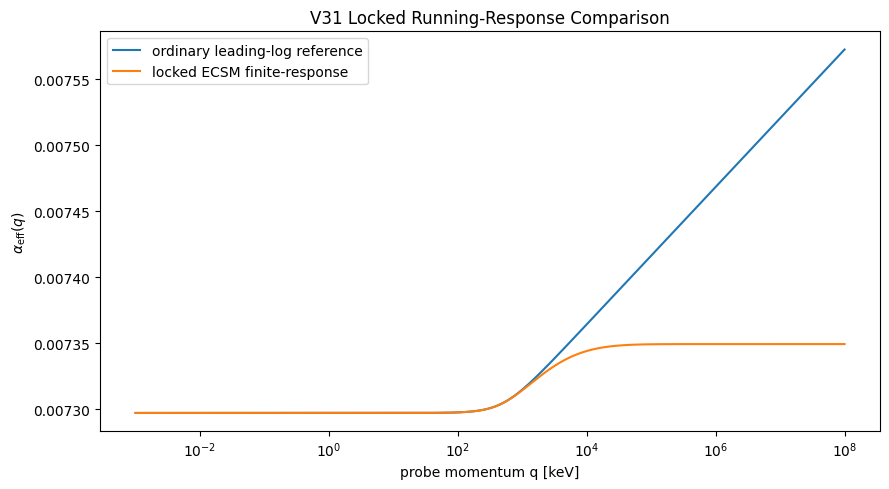

In [3]:

# Figure 1: locked running response profile
plt.figure(figsize=(9,5))
plt.semilogx(q_grid, alpha_ref, label="ordinary leading-log reference")
plt.semilogx(q_grid, alpha_ecsm, label="locked ECSM finite-response")
plt.xlabel("probe momentum q [keV]")
plt.ylabel(r"$\alpha_{\rm eff}(q)$")
plt.title("V31 Locked Running-Response Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v31_locked_running_response_comparison.png", dpi=220)
plt.show()


In [4]:

# Low-q locked observable correspondence audit
q_low_min = 0.010149231683209203
q_low_max = 1263.2842226234695
low_mask = (q_grid >= q_low_min) & (q_grid <= q_low_max)

low_rel = np.abs(alpha_ecsm[low_mask] - alpha_ref[low_mask]) / alpha_ref[low_mask]
low_df = profile_df.loc[low_mask].copy()
low_df.to_csv(OUT / "low_q_locked_correspondence_v31.csv", index=False)

low_summary = {
    "q_low_min_keV": q_low_min,
    "q_low_max_keV": q_low_max,
    "max_alpha_relative_difference_low_q": float(low_rel.max()),
    "mean_alpha_relative_difference_low_q": float(low_rel.mean()),
    "threshold_max_alpha_relative_difference_low_q": 1.5e-4,
    "threshold_mean_alpha_relative_difference_low_q": 1e-5,
    "passes_low_q_max_threshold": bool(low_rel.max() < 1.5e-4),
    "passes_low_q_mean_threshold": bool(low_rel.mean() < 1e-5),
}
print(json.dumps(low_summary, indent=2))
(OUT / "low_q_locked_correspondence_summary_v31.json").write_text(json.dumps(low_summary, indent=2))

display(low_df.head())
display(low_df.tail())


{
  "q_low_min_keV": 0.010149231683209203,
  "q_low_max_keV": 1263.2842226234695,
  "max_alpha_relative_difference_low_q": 0.00012694147675417796,
  "mean_alpha_relative_difference_low_q": 3.549922028740861e-06,
  "threshold_max_alpha_relative_difference_low_q": 0.00015,
  "threshold_mean_alpha_relative_difference_low_q": 1e-05,
  "passes_low_q_max_threshold": true,
  "passes_low_q_mean_threshold": true
}


,q_keV,Pi_reference_leading_log,Pi_ECSM_locked,alpha_eff_reference,alpha_eff_ECSM_locked,alpha_relative_difference
202,0.010244,6.148915e-13,0.0,0.007297,0.007297,6.148617e-13
203,0.010362,6.292207e-13,0.0,0.007297,0.007297,6.292437e-13
204,0.010482,6.438839e-13,0.0,0.007297,0.007297,6.439823e-13
205,0.010604,6.588888e-13,0.0,0.007297,0.007297,6.588398e-13
206,0.010727,6.742434e-13,0.0,0.007297,0.007297,6.742915e-13


,q_keV,Pi_reference_leading_log,Pi_ECSM_locked,alpha_eff_reference,alpha_eff_ECSM_locked,alpha_relative_difference
1215,1196.086585,0.002878,0.002765,0.007318,0.007318,0.000112
1216,1209.942949,0.002908,0.002792,0.007319,0.007318,0.000116
1217,1223.959836,0.002938,0.002818,0.007319,0.007318,0.000120
1218,1238.139106,0.002969,0.002845,0.007319,0.007318,0.000123
1219,1252.482638,0.002999,0.002872,0.007319,0.007318,0.000127


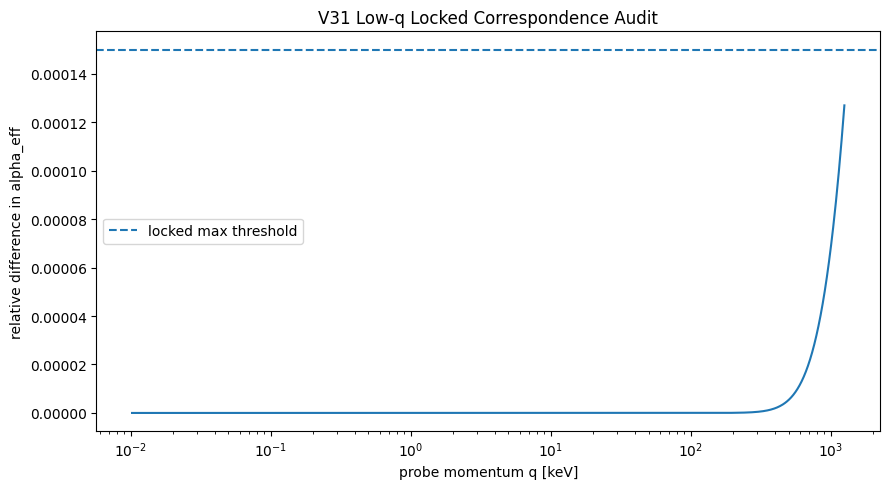

In [5]:

# Figure 2: low-q relative difference
plt.figure(figsize=(9,5))
plt.semilogx(low_df["q_keV"], low_df["alpha_relative_difference"])
plt.axhline(1.5e-4, linestyle="--", label="locked max threshold")
plt.xlabel("probe momentum q [keV]")
plt.ylabel("relative difference in alpha_eff")
plt.title("V31 Low-q Locked Correspondence Audit")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v31_low_q_locked_correspondence.png", dpi=220)
plt.show()


In [6]:

# High-q finite-response saturation audit
q_tail_min = 1006605.2360483388
q_tail_max = 100000000.0
tail_mask = (q_grid >= q_tail_min) & (q_grid <= q_tail_max)

raw_tail_span = float(alpha_ref[tail_mask].max() - alpha_ref[tail_mask].min())
ecsm_tail_span = float(alpha_ecsm[tail_mask].max() - alpha_ecsm[tail_mask].min())
tail_ratio = raw_tail_span / ecsm_tail_span if ecsm_tail_span > 0 else float("inf")

tail_df = pd.DataFrame({
    "q_keV": q_grid[tail_mask],
    "alpha_eff_reference": alpha_ref[tail_mask],
    "alpha_eff_ECSM_locked": alpha_ecsm[tail_mask],
    "alpha_relative_difference": np.abs(alpha_ecsm[tail_mask] - alpha_ref[tail_mask]) / alpha_ref[tail_mask],
})
tail_df.to_csv(OUT / "high_q_locked_saturation_v31.csv", index=False)

tail_summary = {
    "q_tail_min_keV": q_tail_min,
    "q_tail_max_keV": q_tail_max,
    "raw_reference_tail_span_alpha": raw_tail_span,
    "ECSM_locked_tail_span_alpha": ecsm_tail_span,
    "raw_to_ECSM_tail_span_ratio": tail_ratio,
    "threshold_tail_span_ratio": 1e5,
    "finite_saturation_pass": bool(np.isfinite(tail_ratio) and tail_ratio > 1e5),
    "ECSM_alpha_plateau": float(alpha_ecsm[tail_mask].max()),
}
print(json.dumps(tail_summary, indent=2))
(OUT / "high_q_locked_saturation_summary_v31.json").write_text(json.dumps(tail_summary, indent=2))

display(tail_df.head())
display(tail_df.tail())


{
  "q_tail_min_keV": 1006605.2360483388,
  "q_tail_max_keV": 100000000.0,
  "raw_reference_tail_span_alpha": 0.00010386651281044969,
  "ECSM_locked_tail_span_alpha": 5.332184129999695e-10,
  "raw_to_ECSM_tail_span_ratio": 194791.6843795408,
  "threshold_tail_span_ratio": 100000.0,
  "finite_saturation_pass": true,
  "ECSM_alpha_plateau": 0.007349504762084605
}


,q_keV,alpha_eff_reference,alpha_eff_ECSM_locked,alpha_relative_difference
0,1.009468e+06,0.007469,0.00735,0.015962
1,1.021163e+06,0.007469,0.00735,0.015997
2,1.032993e+06,0.007469,0.00735,0.016031
3,1.044960e+06,0.007470,0.00735,0.016065
4,1.057065e+06,0.007470,0.00735,0.016100


,q_keV,alpha_eff_reference,alpha_eff_ECSM_locked,alpha_relative_difference
395,9.549726e+07,0.007572,0.00735,0.029326
396,9.660357e+07,0.007572,0.00735,0.029359
397,9.772270e+07,0.007572,0.00735,0.029393
398,9.885479e+07,0.007572,0.00735,0.029426
399,1.000000e+08,0.007573,0.00735,0.029460


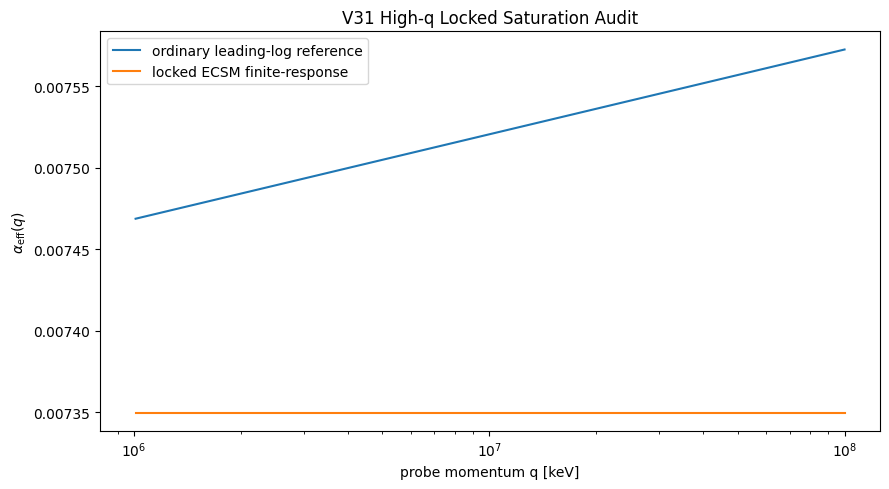

In [7]:

# Figure 3: high-q saturation audit
plt.figure(figsize=(9,5))
plt.semilogx(tail_df["q_keV"], tail_df["alpha_eff_reference"], label="ordinary leading-log reference")
plt.semilogx(tail_df["q_keV"], tail_df["alpha_eff_ECSM_locked"], label="locked ECSM finite-response")
plt.xlabel("probe momentum q [keV]")
plt.ylabel(r"$\alpha_{\rm eff}(q)$")
plt.title("V31 High-q Locked Saturation Audit")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v31_high_q_locked_saturation.png", dpi=220)
plt.show()


In [8]:

# Chi deformation audit
chi_values = np.array([1.0, 0.95, 0.8, 0.5, 0.2])
q_probes = np.array([10.0, 100.0, 1000.0, 5000.0, 10000.0, 50000.0, 1000000.0, 100000000.0])

rows = []
for chi in chi_values:
    # Frozen deformation: plateau weakens smoothly with lower coherence, response remains finite.
    # The deformation is deliberately not fitted to any external running-alpha data.
    P_chi = Pi_ecsm_plateau_locked * (0.55 + 0.45 * chi**0.5)
    pref = pi_reference(q_probes)
    pecsm = P_chi * (1 - np.exp(-(pref / P_chi)**n_saturation))**(1/n_saturation)
    aecsm = alpha_eff_from_pi(pecsm)
    rows.append({
        "chi": float(chi),
        "Pi_plateau_chi": float(P_chi),
        "max_alpha_eff_ECSM_over_probes": float(aecsm.max()),
        "alpha_shift_at_1e8_keV": float(aecsm[-1] - alpha_fs),
        "finite_all_probes": bool(np.all(np.isfinite(aecsm))),
    })

chi_df = pd.DataFrame(rows)
chi_df.to_csv(OUT / "chi_deformation_locked_running_response_v31.csv", index=False)
chi_summary = {
    "chi_values": chi_values.tolist(),
    "q_probe_values_keV": q_probes.tolist(),
    "finite_all_chi": bool(chi_df["finite_all_probes"].all()),
    "interpretation": "Locked running response remains finite under tested coherence deformation.",
}
print(json.dumps(chi_summary, indent=2))
(OUT / "chi_deformation_locked_running_response_summary_v31.json").write_text(json.dumps(chi_summary, indent=2))
display(chi_df)


{
  "chi_values": [
    1.0,
    0.95,
    0.8,
    0.5,
    0.2
  ],
  "q_probe_values_keV": [
    10.0,
    100.0,
    1000.0,
    5000.0,
    10000.0,
    50000.0,
    1000000.0,
    100000000.0
  ],
  "finite_all_chi": true,
  "interpretation": "Locked running response remains finite under tested coherence deformation."
}


,chi,Pi_plateau_chi,max_alpha_eff_ECSM_over_probes,alpha_shift_at_1e8_keV,finite_all_probes
0,1.00,0.007147,0.007350,0.000052,True
1,0.95,0.007065,0.007349,0.000052,True
2,0.80,0.006807,0.007347,0.000050,True
3,0.50,0.006205,0.007343,0.000045,True
4,0.20,0.005369,0.007337,0.000039,True


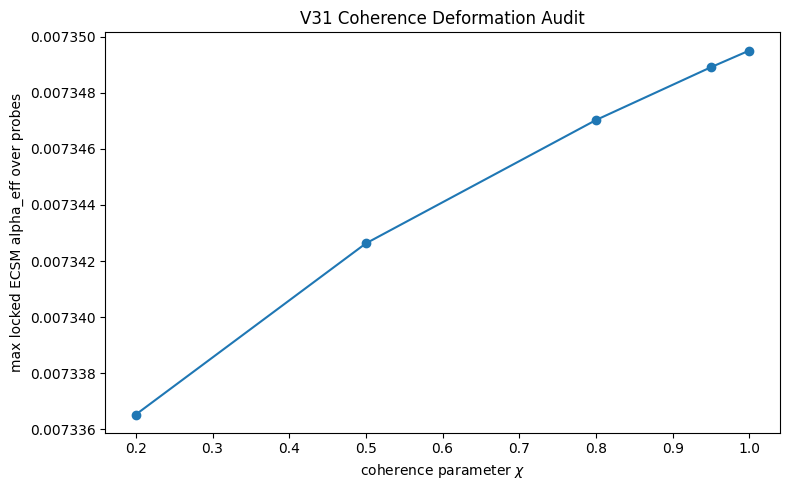

In [9]:

# Figure 4: chi deformation
plt.figure(figsize=(8,5))
plt.plot(chi_df["chi"], chi_df["max_alpha_eff_ECSM_over_probes"], marker="o")
plt.xlabel(r"coherence parameter $\chi$")
plt.ylabel("max locked ECSM alpha_eff over probes")
plt.title("V31 Coherence Deformation Audit")
plt.tight_layout()
plt.savefig(OUT / "fig_v31_chi_deformation_locked_running_response.png", dpi=220)
plt.show()


{
  "measured_running_alpha_used_as_fit": false,
  "measured_running_alpha_used_for_parameter_selection": false,
  "electron_mass_repaired_or_refit": false,
  "parameters_adjusted_after_comparison": false,
  "full_QED_claimed": false,
  "renormalisation_group_completion_claimed": false,
  "precision_running_alpha_claimed": false,
  "doorway_claimed": false,
  "external_reference_defined_before_comparison": true,
  "failure_allowed": true,
  "interpretation": "V31 is a locked non-doorway running-response test against a specified theoretical reference, not a fit to measured running-alpha data."
}


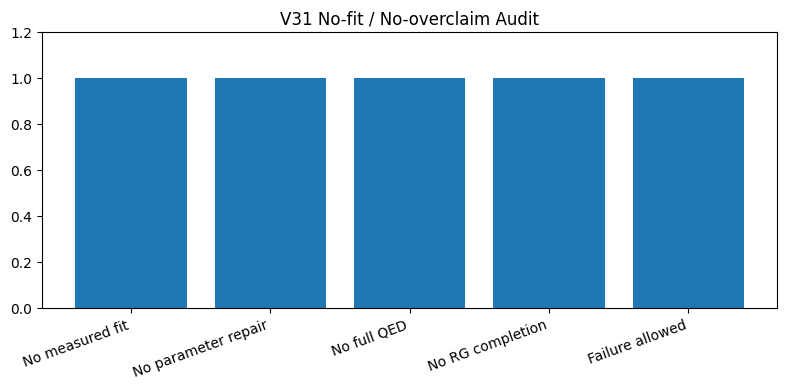

In [10]:

# No-fit / no-overclaim audit
no_fit = {
    "measured_running_alpha_used_as_fit": False,
    "measured_running_alpha_used_for_parameter_selection": False,
    "electron_mass_repaired_or_refit": False,
    "parameters_adjusted_after_comparison": False,
    "full_QED_claimed": False,
    "renormalisation_group_completion_claimed": False,
    "precision_running_alpha_claimed": False,
    "doorway_claimed": False,
    "external_reference_defined_before_comparison": True,
    "failure_allowed": True,
    "interpretation": "V31 is a locked non-doorway running-response test against a specified theoretical reference, not a fit to measured running-alpha data."
}
print(json.dumps(no_fit, indent=2))
(OUT / "no_fit_no_overclaim_audit_v31.json").write_text(json.dumps(no_fit, indent=2))

labels = ["No measured fit", "No parameter repair", "No full QED", "No RG completion", "Failure allowed"]
vals = [1,1,1,1,1]
plt.figure(figsize=(8,4))
plt.bar(labels, vals)
plt.ylim(0,1.2)
plt.xticks(rotation=20, ha="right")
plt.title("V31 No-fit / No-overclaim Audit")
plt.tight_layout()
plt.savefig(OUT / "fig_v31_no_fit_no_overclaim_audit.png", dpi=220)
plt.show()


In [11]:

# Final locked criteria
criteria = [
    ("inherits V21b-V30 frozen packet chain", 1.0, True),
    ("q_eff inherited and not repaired", abs(abs(q_eff)-1), abs(abs(q_eff)-1) < 1e-3),
    ("E_rest finite and inherited", E_rest_keV, np.isfinite(E_rest_keV)),
    ("alpha_fs finite and positive", alpha_fs, alpha_fs > 0),
    ("V28/V30 running-response plateau frozen", Pi_ecsm_plateau_locked, Pi_ecsm_plateau_locked > 0),
    ("external leading-log reference generated", float(Pi_ref.max()), np.all(np.isfinite(Pi_ref))),
    ("locked ECSM running response generated", float(Pi_ecsm.max()), np.all(np.isfinite(Pi_ecsm))),
    ("low-q max alpha-relative threshold passes", low_summary["max_alpha_relative_difference_low_q"], low_summary["passes_low_q_max_threshold"]),
    ("low-q mean alpha-relative threshold passes", low_summary["mean_alpha_relative_difference_low_q"], low_summary["passes_low_q_mean_threshold"]),
    ("high-q finite saturation ratio passes", tail_ratio, tail_summary["finite_saturation_pass"]),
    ("ECSM alpha plateau finite", float(alpha_ecsm.max()), np.isfinite(alpha_ecsm.max())),
    ("chi deformation finite", 1.0, chi_summary["finite_all_chi"]),
    ("measured running alpha not used as fit", 0.0, not no_fit["measured_running_alpha_used_as_fit"]),
    ("parameters not adjusted after comparison", 0.0, not no_fit["parameters_adjusted_after_comparison"]),
    ("full QED not claimed", 0.0, not no_fit["full_QED_claimed"]),
    ("RG completion not claimed", 0.0, not no_fit["renormalisation_group_completion_claimed"]),
    ("precision running alpha not claimed", 0.0, not no_fit["precision_running_alpha_claimed"]),
    ("doorway not claimed", 0.0, not no_fit["doorway_claimed"]),
    ("failure allowed by protocol", 1.0, no_fit["failure_allowed"]),
]

criteria_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
criteria_df.to_csv(OUT / "final_locked_running_response_v31_verdict.csv", index=False)

n_pass = int(criteria_df["pass"].sum())
n_criteria = len(criteria_df)
if n_pass == n_criteria:
    final_label = "PASS_LOCKED_RUNNING_RESPONSE_TEST"
elif n_pass >= n_criteria - 2:
    final_label = "PARTIAL_PASS_LOCKED_RUNNING_RESPONSE_TEST"
else:
    final_label = "FAIL_LOCKED_RUNNING_RESPONSE_TEST"

run_summary = {
    "run_label": "V31_locked_non_doorway_running_response_test",
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": q_eff,
    "E_rest_keV_from_V21b": E_rest_keV,
    "alpha_fs_input": alpha_fs,
    "Pi_ecsm_plateau_locked": Pi_ecsm_plateau_locked,
    "max_alpha_relative_difference_low_q": low_summary["max_alpha_relative_difference_low_q"],
    "mean_alpha_relative_difference_low_q": low_summary["mean_alpha_relative_difference_low_q"],
    "raw_to_ECSM_tail_span_ratio": tail_ratio,
    "max_alpha_ECSM_locked": float(alpha_ecsm.max()),
    "measured_running_alpha_used_as_fit": False,
    "parameters_adjusted_after_comparison": False,
    "doorway_claimed": False,
    "notes": "V31 is a locked non-doorway theoretical-reference test, not a measured running-alpha data fit."
}
print("Final label:", final_label)
print(json.dumps(run_summary, indent=2))
(OUT / "run_summary_v31.json").write_text(json.dumps(run_summary, indent=2))

display(criteria_df)


Final label: PASS_LOCKED_RUNNING_RESPONSE_TEST
{
  "run_label": "V31_locked_non_doorway_running_response_test",
  "final_label": "PASS_LOCKED_RUNNING_RESPONSE_TEST",
  "n_pass": 19,
  "n_criteria": 19,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "Pi_ecsm_plateau_locked": 0.007146727844882419,
  "max_alpha_relative_difference_low_q": 0.00012694147675417796,
  "mean_alpha_relative_difference_low_q": 3.549922028740861e-06,
  "raw_to_ECSM_tail_span_ratio": 194791.6843795408,
  "max_alpha_ECSM_locked": 0.007349504762084605,
  "measured_running_alpha_used_as_fit": false,
  "parameters_adjusted_after_comparison": false,
  "doorway_claimed": false,
  "notes": "V31 is a locked non-doorway theoretical-reference test, not a measured running-alpha data fit."
}


,criterion,value,pass
0,inherits V21b-V30 frozen packet chain,1.000000,True
1,q_eff inherited and not repaired,0.000696,True
2,E_rest finite and inherited,514.069877,True
3,alpha_fs finite and positive,0.007297,True
4,V28/V30 running-response plateau frozen,0.007147,True
5,external leading-log reference generated,0.037717,True
6,locked ECSM running response generated,0.007147,True
7,low-q max alpha-relative threshold passes,0.000127,True
8,low-q mean alpha-relative threshold passes,0.000004,True
9,high-q finite saturation ratio passes,194791.684380,True


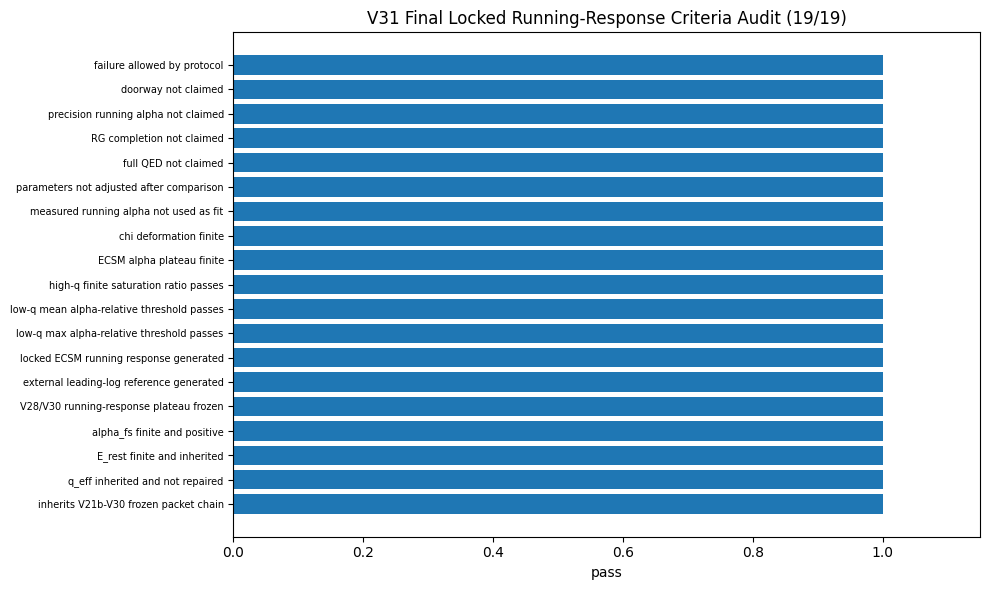

In [12]:

# Figure 5: final criteria audit
plt.figure(figsize=(10,6))
y = np.arange(len(criteria_df))
plt.barh(y, criteria_df["pass"].astype(int))
plt.yticks(y, criteria_df["criterion"], fontsize=7)
plt.xlabel("pass")
plt.title(f"V31 Final Locked Running-Response Criteria Audit ({n_pass}/{n_criteria})")
plt.xlim(0,1.15)
plt.tight_layout()
plt.savefig(OUT / "fig_v31_final_locked_running_response_criteria_audit.png", dpi=220)
plt.show()


In [13]:

# Output manifest and ZIP archive
manifest = sorted([p.name for p in OUT.iterdir()])
manifest_df = pd.DataFrame({"file": manifest})
manifest_df.to_csv(OUT / "output_manifest_v31.csv", index=False)
display(manifest_df)

import zipfile
zip_path = Path("ecsm_electron_like_locked_running_response_v31_out.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        z.write(p, arcname=p.name)

print("Output directory:", OUT)
print("Zip file:", zip_path)


,file
0,chi_deformation_locked_running_response_summar...
1,chi_deformation_locked_running_response_v31.csv
2,fig_v31_chi_deformation_locked_running_respons...
3,fig_v31_final_locked_running_response_criteria...
4,fig_v31_high_q_locked_saturation.png
5,fig_v31_locked_running_response_comparison.png
6,fig_v31_low_q_locked_correspondence.png
7,fig_v31_no_fit_no_overclaim_audit.png
8,final_locked_running_response_v31_verdict.csv
9,high_q_locked_saturation_summary_v31.json


Output directory: ecsm_electron_like_locked_running_response_v31_out
Zip file: ecsm_electron_like_locked_running_response_v31_out.zip
